===== BEFORE TUNING =====
Multiple Linear Regression -> R2: 0.7910, MSE: 1603216326.54
Ridge -> R2: 0.7910, MSE: 1603229768.45
Lasso -> R2: 0.7910, MSE: 1603216846.12

Feature Importance (Multiple Regression):
       Feature   Coefficient
0      LotArea      0.689246
1  OverallQual  22968.061502
2    YearBuilt    446.892086
3  TotalBsmtSF     23.347464
4    GrLivArea     50.561382


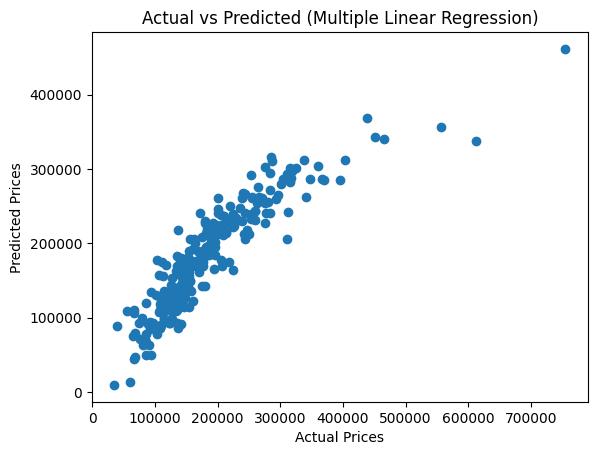

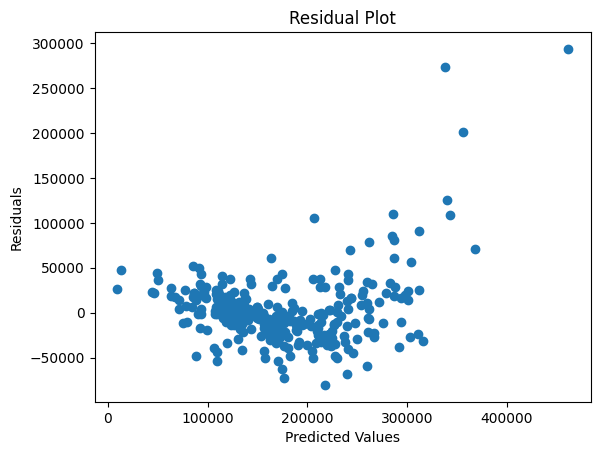


===== AFTER TUNING =====
Ridge Tuned -> R2: 0.7910, MSE: 1603390912.83
Lasso Tuned -> R2: 0.7910, MSE: 1603216379.41


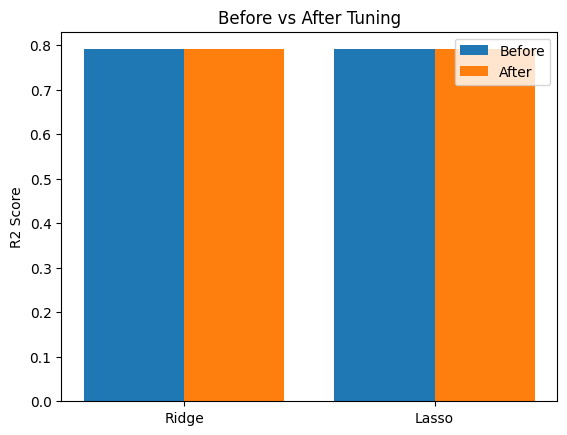

In [3]:
# ==========================================
# MULTIPLE LINEAR REGRESSION + RIDGE + LASSO
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error

# ==========================================
# LOAD DATASET
# ==========================================
df = pd.read_csv('/content/train.csv')

# ==========================================
# SELECT MULTIPLE FEATURES
# ==========================================
df = df[['LotArea','OverallQual','YearBuilt','TotalBsmtSF','GrLivArea','SalePrice']]
df = df.dropna()

# ==========================================
# SPLIT DATA
# ==========================================
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# BEFORE TUNING
# ==========================================
print("===== BEFORE TUNING =====")

models = {
    "Multiple Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso()
}

results_before = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    mse = mean_squared_error(y_test, pred)

    results_before[name] = r2

    print(f"{name} -> R2: {r2:.4f}, MSE: {mse:.2f}")

# ==========================================
# FEATURE IMPORTANCE (COEFFICIENTS)
# ==========================================
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": models["Multiple Linear Regression"].coef_
})

print("\nFeature Importance (Multiple Regression):")
print(coef_df)

# ==========================================
# GRAPH 1: ACTUAL VS PREDICTED
# ==========================================
plt.figure()
plt.scatter(y_test, models["Multiple Linear Regression"].predict(X_test))
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted (Multiple Linear Regression)")
plt.show()

# ==========================================
# GRAPH 2: RESIDUAL PLOT
# ==========================================
residuals = y_test - models["Multiple Linear Regression"].predict(X_test)

plt.figure()
plt.scatter(models["Multiple Linear Regression"].predict(X_test), residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# ==========================================
# HYPERPARAMETER TUNING
# ==========================================
ridge_params = {"alpha": [0.1, 1, 10]}
lasso_params = {"alpha": [0.001, 0.01, 0.1]}

ridge_cv = GridSearchCV(Ridge(), ridge_params, cv=5)
lasso_cv = GridSearchCV(Lasso(), lasso_params, cv=5)

ridge_cv.fit(X_train, y_train)
lasso_cv.fit(X_train, y_train)

# ==========================================
# AFTER TUNING
# ==========================================
print("\n===== AFTER TUNING =====")

ridge_best = ridge_cv.best_estimator_
lasso_best = lasso_cv.best_estimator_

results_after = {}

for name, model in [("Ridge Tuned", ridge_best), ("Lasso Tuned", lasso_best)]:
    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    mse = mean_squared_error(y_test, pred)

    results_after[name] = r2

    print(f"{name} -> R2: {r2:.4f}, MSE: {mse:.2f}")

# ==========================================
# GRAPH 3: BEFORE VS AFTER
# ==========================================
labels = ['Ridge', 'Lasso']
before = [results_before['Ridge'], results_before['Lasso']]
after = [results_after['Ridge Tuned'], results_after['Lasso Tuned']]

x = np.arange(len(labels))

plt.figure()
plt.bar(x - 0.2, before, width=0.4, label='Before')
plt.bar(x + 0.2, after, width=0.4, label='After')

plt.xticks(x, labels)
plt.ylabel("R2 Score")
plt.title("Before vs After Tuning")
plt.legend()
plt.show()